Selected Best Configurations:
                   Model  Batch_Size  Accuracy  Energy_Wh
0  Llama-3.2-1B-Instruct          20   28.6919   0.429887
1  Llama-3.2-3B-Instruct          10   67.2123   4.460635
2             Qwen3-0.6B           5   62.4474   2.429844
3             Qwen3-1.7B          10   69.7448   3.532707
4               Qwen3-4B           5   77.5965   9.499830
5               Qwen3-8B          20   73.7805   2.694809
6   Qwen3-VL-2B-Instruct          10   77.0864   7.497901
7   Qwen3-VL-4B-Instruct           5   73.0372  13.775308


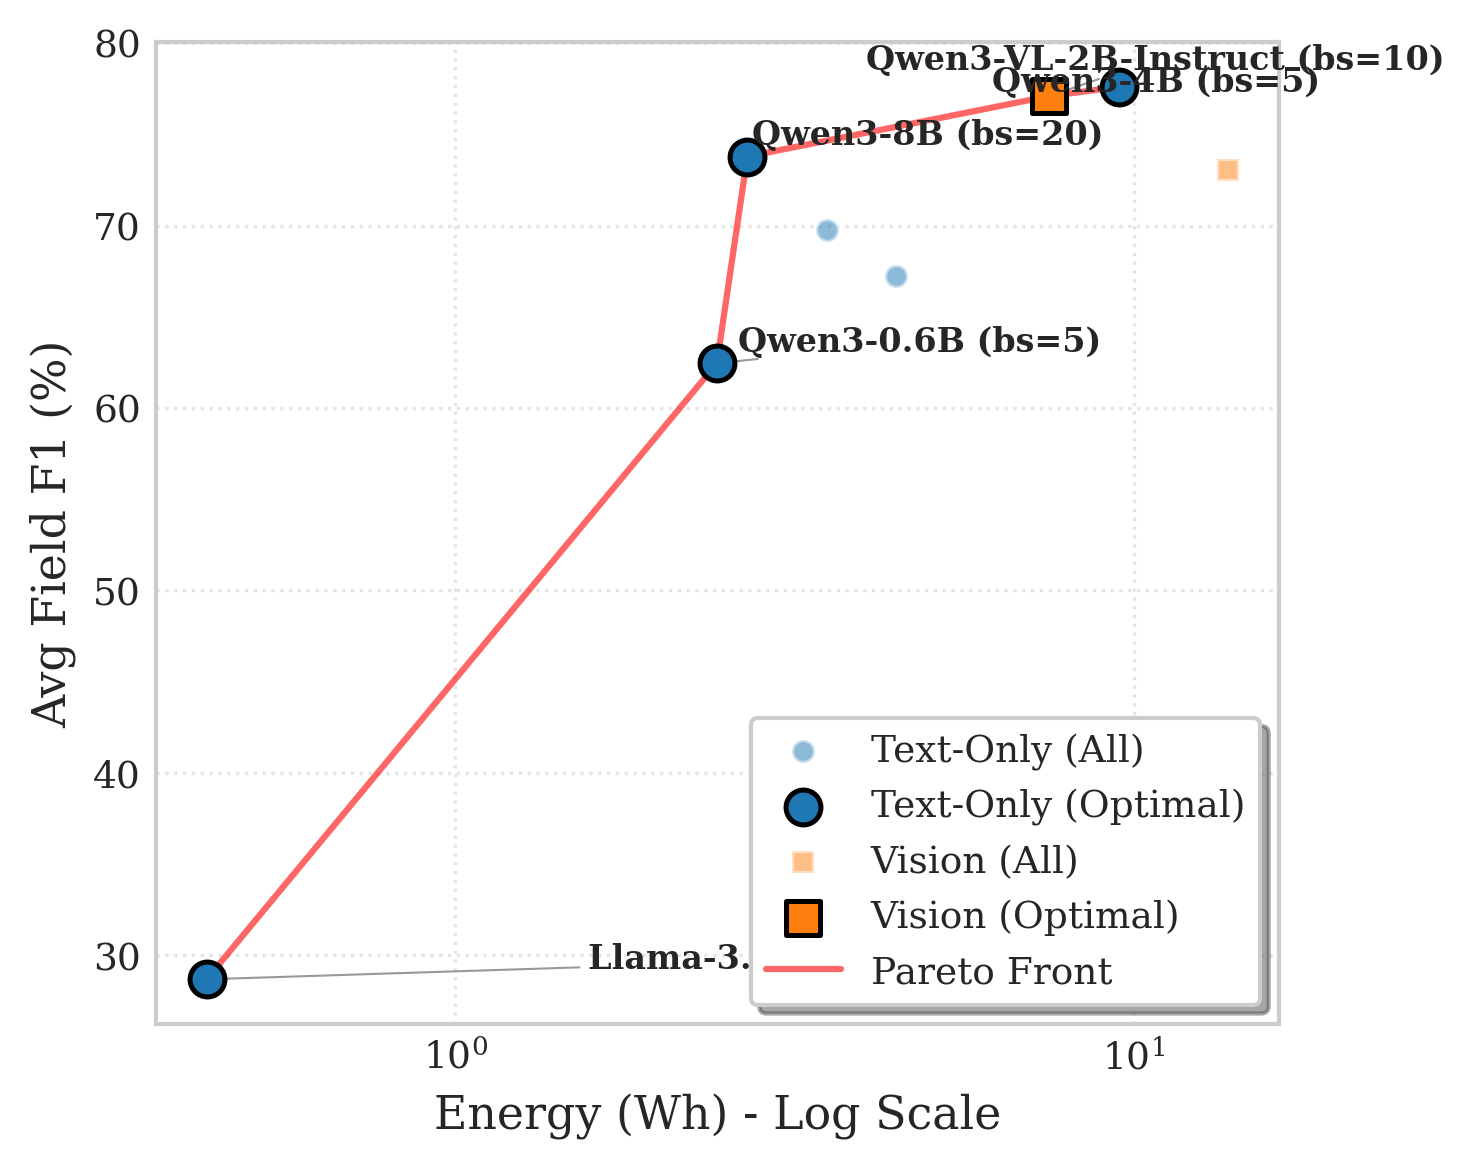

In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
from adjustText import adjust_text

# 1. Define the paths where your reports are stored
paths = [
    "../vrdu_text_only/run_report/*.csv",
    "../vrdu_vision/run_report/*.csv"
]

# Gather all CSV files
all_files = []
for path in paths:
    all_files.extend(glob.glob(path))

# 2. Read all files into a list of dictionaries
data_list = []
for file in all_files:
    try:
        df_temp = pd.read_csv(file)
        model_name = df_temp['model_name'].iloc[0]
        accuracy = df_temp['avg_field_f1'].iloc[0] * 100
        energy = df_temp['total_energy_wh'].iloc[0]

        # Safely extract batch size (defaults to 1 if it's a "single" scenario)
        batch_size = df_temp['batch_size'].iloc[0] if 'batch_size' in df_temp.columns else 1

        modality = "Vision" if "vrdu_vision" in file else "Text-Only"

        data_list.append({
            'Model': model_name,
            'Batch_Size': batch_size,
            'Accuracy': accuracy,
            'Energy_Wh': energy,
            'Modality': modality
        })
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Create the full DataFrame of ALL configurations
df_all = pd.DataFrame(data_list)

# 3. SELECT THE BEST CONFIGURATION PER MODEL
# Sort by Model, then Accuracy (Highest First), then Energy (Lowest First)
df_sorted = df_all.sort_values(
    by=['Model', 'Accuracy', 'Energy_Wh'],
    ascending=[True, False, True]
)
# Keep only the first row for each model (which will be the best one based on our sort)
df = df_sorted.drop_duplicates(subset=['Model'], keep='first').reset_index(drop=True)

# (Optional) Print out the winning configurations to verify
print("Selected Best Configurations:")
print(df[['Model', 'Batch_Size', 'Accuracy', 'Energy_Wh']])

# 4. Calculate the Pareto Frontier
df = df.sort_values('Energy_Wh').reset_index(drop=True)
pareto_front_x, pareto_front_y, pareto_models = [], [], []
max_acc = -1

for index, row in df.iterrows():
    if row['Accuracy'] > max_acc:
        pareto_front_x.append(row['Energy_Wh'])
        pareto_front_y.append(row['Accuracy'])
        pareto_models.append(row['Model'])
        max_acc = row['Accuracy']

# 5. Plotting (ACL Formatting)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.figsize': (5.0, 4.0),
    'figure.dpi': 300
})

fig, ax = plt.subplots()
colors = {'Text-Only': '#1f77b4', 'Vision': '#ff7f0e'}
markers = {'Text-Only': 'o', 'Vision': 's'}

for modality in df['Modality'].unique():
    subset = df[df['Modality'] == modality]
    is_pareto = subset['Model'].isin(pareto_models)

    # Sub-optimal points
    ax.scatter(subset[~is_pareto]['Energy_Wh'], subset[~is_pareto]['Accuracy'],
               s=30, c=colors[modality], marker=markers[modality],
               edgecolors='white', alpha=0.5, label=f"{modality} (All)", zorder=2)

    # Pareto-optimal points
    ax.scatter(subset[is_pareto]['Energy_Wh'], subset[is_pareto]['Accuracy'],
               s=70, c=colors[modality], marker=markers[modality],
               edgecolors='black', linewidths=1.2, alpha=1.0, label=f"{modality} (Optimal)", zorder=4)

ax.plot(pareto_front_x, pareto_front_y, '-', color='red', linewidth=1.5, alpha=0.6, zorder=3, label='Pareto Front')

# 6. Annotations (Include the winning batch size in the label for transparency!)
texts = []
for i, row in df.iterrows():
    if row['Model'] in pareto_models:
        # e.g., "Qwen3-VL-4B (bs=10)"
        label = f"{row['Model']} (bs={int(row['Batch_Size'])})"
        texts.append(ax.text(row['Energy_Wh'], row['Accuracy'], label,
                             fontsize=8, fontweight='bold', zorder=5))

adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5, alpha=0.8), ax=ax)

ax.set_xscale('log')
ax.set_xlabel('Energy (Wh) - Log Scale')
ax.set_ylabel('Avg Field F1 (%)')

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='lower right', frameon=True, shadow=True)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('acl_pareto_vrdu_best_configs.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [2]:
# Sort by energy consumption (ascending)
df = df.sort_values('Energy_Wh').reset_index(drop=True)

pareto_front_x = []
pareto_front_y = []
max_acc = -1

# Iterate through the sorted dataframe
for index, row in df.iterrows():
    # If the current model has a strictly better accuracy than the max seen so far,
    # it is on the Pareto frontier.
    if row['Accuracy'] > max_acc:
        pareto_front_x.append(row['Energy_Wh'])
        pareto_front_y.append(row['Accuracy'])
        max_acc = row['Accuracy']

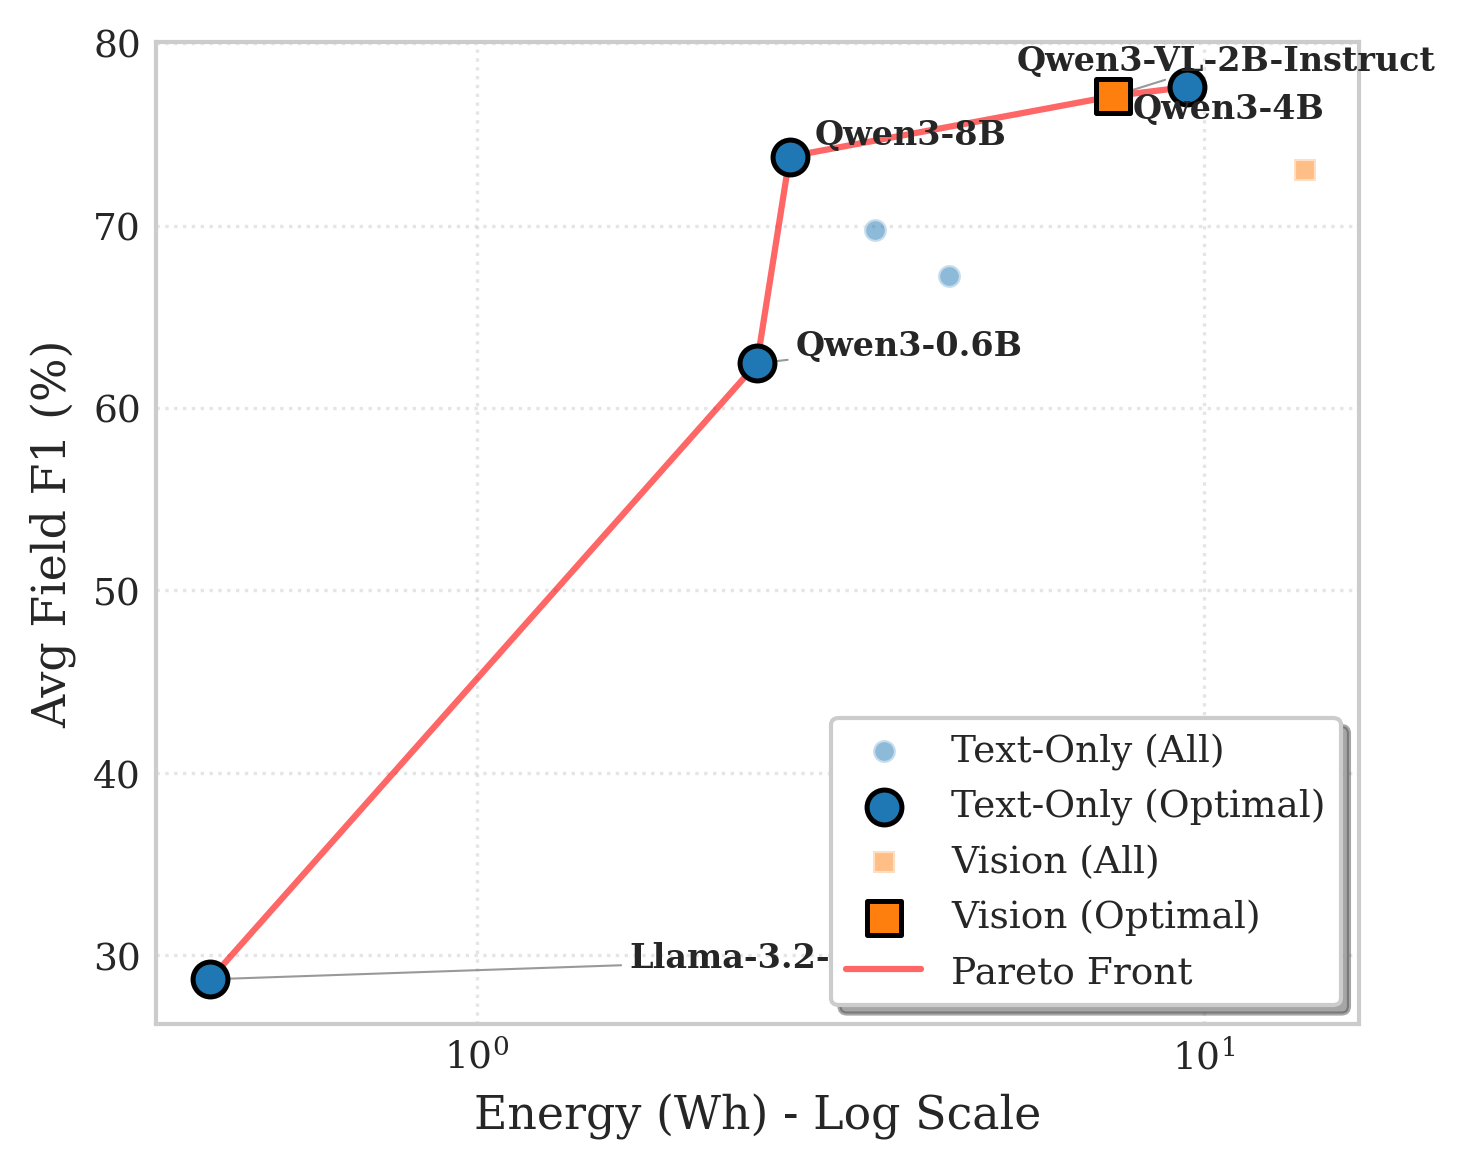

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text

# ... [Assume 'df' is loaded and aggregated exactly as in the previous step] ...

# 1. Calculate the Pareto Frontier AND track which models are on it
df = df.sort_values('Energy_Wh').reset_index(drop=True)

pareto_front_x = []
pareto_front_y = []
pareto_models = [] # Track the names of optimal models
max_acc = -1

for index, row in df.iterrows():
    if row['Accuracy'] > max_acc:
        pareto_front_x.append(row['Energy_Wh'])
        pareto_front_y.append(row['Accuracy'])
        pareto_models.append(row['Model'])
        max_acc = row['Accuracy']

# 2. Configure for Academic paper (ACL format)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.figsize': (5.0, 4.0), # Slightly wider to give labels room
    'figure.dpi': 300
})

fig, ax = plt.subplots()

# Define colors for modalities
colors = {'Text-Only': '#1f77b4', 'Vision': '#ff7f0e'}
markers = {'Text-Only': 'o', 'Vision': 's'}

# 3. Plot the data points with Transparency (alpha)
for modality in df['Modality'].unique():
    subset = df[df['Modality'] == modality]
    # Highlight points: Check if they are in the pareto front
    is_pareto = subset['Model'].isin(pareto_models)

    # Plot sub-optimal points smaller and more transparent
    ax.scatter(subset[~is_pareto]['Energy_Wh'], subset[~is_pareto]['Accuracy'],
               s=30, c=colors[modality], marker=markers[modality],
               edgecolors='white', alpha=0.5, label=f"{modality} (All)", zorder=2)

    # Plot Pareto-optimal points larger and solid
    ax.scatter(subset[is_pareto]['Energy_Wh'], subset[is_pareto]['Accuracy'],
               s=70, c=colors[modality], marker=markers[modality],
               edgecolors='black', linewidths=1.2, alpha=1.0, label=f"{modality} (Optimal)", zorder=4)

# Plot the Pareto Front line
ax.plot(pareto_front_x, pareto_front_y, '-', color='red', linewidth=1.5, alpha=0.6,
        zorder=3, label='Pareto Front')

# 4. Selective Annotations with adjustText
texts = []
for i, row in df.iterrows():
    # Only create text labels for the optimal models to reduce clutter!
    if row['Model'] in pareto_models:
        texts.append(ax.text(row['Energy_Wh'], row['Accuracy'], row['Model'],
                             fontsize=8, fontweight='bold', zorder=5))

# adjust_text repels labels away from each other and the data points automatically
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=0.5, alpha=0.8), ax=ax)

# Axis labels and formatting
ax.set_xscale('log')
ax.set_xlabel('Energy (Wh) - Log Scale')
ax.set_ylabel('Avg Field F1 (%)')

# Fix legend (prevent duplicates if you have many points)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='lower right', frameon=True, shadow=True)

# Grid lines
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()

# Save out to PDF for your LaTeX document
plt.savefig('acl_pareto_vrdu_improved.pdf', format='pdf', bbox_inches='tight')
plt.show()

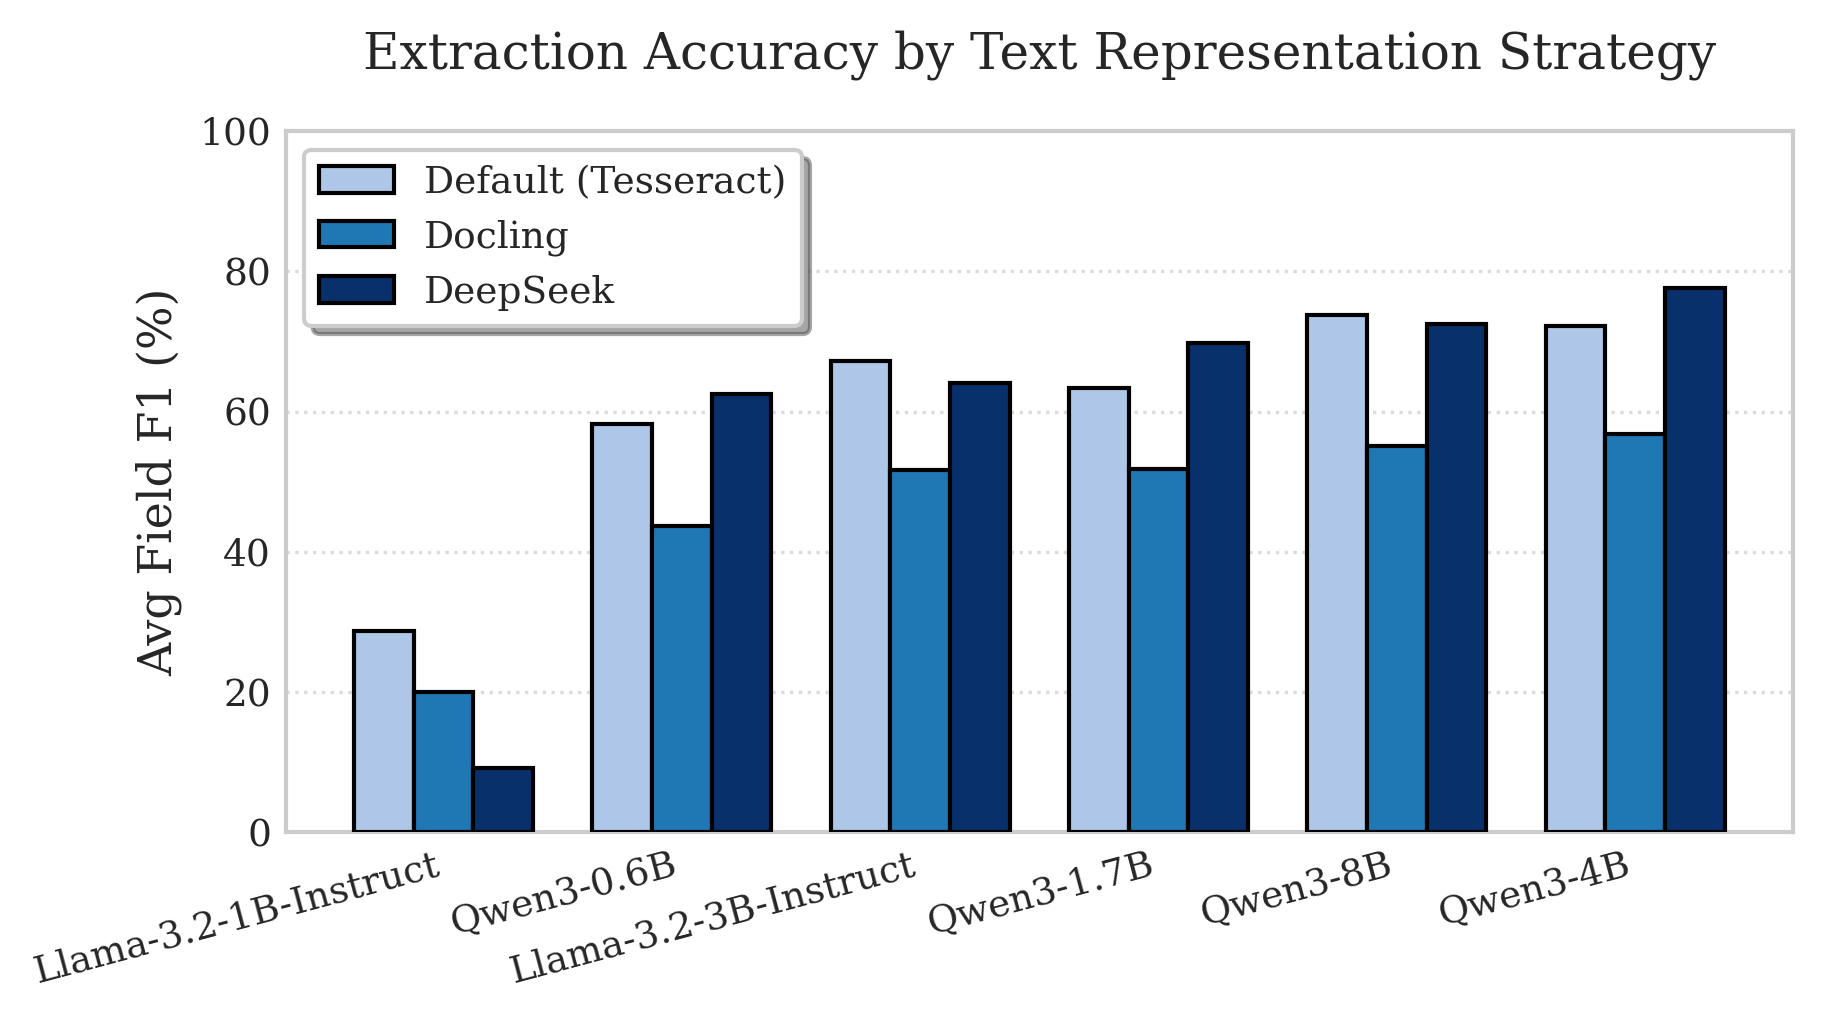

In [4]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np

# 1. Gather all CSV files from the text-only directory
all_files = glob.glob("../vrdu_noquant/run_report/*.csv")

# 2. Read all files into a list of dictionaries
data_list = []
target_tasks = ['vrdu_default', 'vrdu_docling', 'vrdu_deepseek']

for file in all_files:
    try:
        df_temp = pd.read_csv(file)
        task = df_temp['task'].iloc[0]

        # Only process if it's one of the tasks we care about
        if task in target_tasks:
            model_name = df_temp['model_name'].iloc[0]
            accuracy = df_temp['avg_field_f1'].iloc[0] * 100

            data_list.append({
                'Model': model_name,
                'Task': task,
                'Accuracy': accuracy
            })
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Create DataFrame
df_all = pd.DataFrame(data_list)

# 3. Handle multiple runs: Keep the best accuracy per Model + Task combination
df_sorted = df_all.sort_values(by=['Model', 'Task', 'Accuracy'], ascending=[True, True, False])
df_best = df_sorted.drop_duplicates(subset=['Model', 'Task'], keep='first').reset_index(drop=True)

# 4. Pivot the data so Models are rows and Tasks are columns
# This format is required to easily plot a grouped bar chart
pivot_df = df_best.pivot(index='Model', columns='Task', values='Accuracy')

# Ensure columns are in a logical order (e.g., baseline to most advanced)
# If some tasks are missing for some models, fill with 0 for plotting purposes
pivot_df = pivot_df.reindex(columns=target_tasks).fillna(0)

# Sort models by their average performance across tasks so the chart looks organized
pivot_df['mean_acc'] = pivot_df.mean(axis=1)
pivot_df = pivot_df.sort_values('mean_acc', ascending=True).drop(columns=['mean_acc'])

# 5. Plotting (ACL Formatting)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    # A grouped bar chart usually needs the full double-column width (6.2, 3.5)
    'figure.figsize': (6.2, 3.5),
    'figure.dpi': 300
})

fig, ax = plt.subplots()

# Define positions and width for the bars
x = np.arange(len(pivot_df.index))  # Label locations
width = 0.25  # Width of the bars

# Plot each task as a set of bars
# We use distinct but complementary colors
colors = ['#aec7e8', '#1f77b4', '#08306b'] # Light blue to dark blue gradient
labels = ['Default (Tesseract)', 'Docling', 'DeepSeek']

# Offset the bars so they group together
rects1 = ax.bar(x - width, pivot_df['vrdu_default'], width, label=labels[0], color=colors[0], edgecolor='black', zorder=3)
rects2 = ax.bar(x, pivot_df['vrdu_docling'], width, label=labels[1], color=colors[1], edgecolor='black', zorder=3)
rects3 = ax.bar(x + width, pivot_df['vrdu_deepseek'], width, label=labels[2], color=colors[2], edgecolor='black', zorder=3)

# Axis labels and formatting
ax.set_ylabel('Avg Field F1 (%)')
ax.set_title('Extraction Accuracy by Text Representation Strategy', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(pivot_df.index, rotation=15, ha='right') # Rotate labels if model names are long
ax.set_ylim(0, 100) # Assuming F1 is a percentage 0-100

# Legend
ax.legend(loc='upper left', frameon=True, shadow=True)

# Grid lines (only horizontal for bar charts looks cleaner)
ax.grid(True, axis='y', linestyle=':', alpha=0.7, zorder=0)
ax.grid(False, axis='x')

plt.tight_layout()

# Save out to PDF for your LaTeX document
plt.savefig('acl_text_tasks_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()